# SMS Spam Classification with a Neural Network Built from Scratch

**Machine Learning — text-analysis assignment**

## Part 1 — Introduction

### Students

| Family name | ID (first 4 digits) |
|---|---|
| Buskila | TODO(team) |
| TODO(team: Liav's family name) | TODO(team) |

### AI assistants we used

We used **Claude Code (Anthropic, model Claude Fable 5)** as a pair programmer throughout the project.
The full, dated prompt log with links is in [`docs/prompts-log.md`](../docs/prompts-log.md); in short:

| What we asked for | Examples of prompts | Conversation |
|---|---|---|
| Reading the assignment, choosing a dataset that ships a train/test split, planning the work | "we made the decisions and downloaded the dataset, lets continue" · "how can i pick one thats already split" | [session link](https://claude.ai/code/session_019XxZC9ESBsXSmwJUA5PudP) |
| Writing the design spec and implementation plan, then the code and tests, with us reviewing each step | "approved, write the plan and start" | same session |

Everything the assistant produced was read, run and tested by us; the learning algorithm in `src/ann.py`
is verified by a numerical gradient check (Part 3) and a suite of 100+ unit tests (`tests/`).

### The learning problem

**Binary text classification.** Given the text of an SMS message, predict whether it is **spam**
(unsolicited advertising / scams — the positive class) or **not spam** (a normal personal message).
The motivation is the classic spam filter: catch as much spam as possible without hiding real messages
from the user. Because both error types matter and the classes are imbalanced, the quality metric
prescribed by the assignment for binary problems is the **F1 score of the positive class (Spam)**.

### The dataset

* Kaggle: **E-Mail classification NLP** — <https://www.kaggle.com/datasets/datatattle/email-classification-nlp>
  (despite the title, the rows are SMS messages from the well-known SMS Spam Collection).
* Kaggle ships **two files**, and we use them exactly as given — we never re-split, shuffle or de-duplicate:
  `SMS_train.csv` (957 messages) for everything up to and including model selection, and
  `SMS_test.csv` (125 messages), which is opened only in Part 5.
* Columns: `S. No.` (row number), `Message_body` (the text), `Label` ∈ {`Spam`, `Non-Spam`}.
* The files are encoded in Windows-1252 (the `£` sign is byte `0xA3`), so they are read with `encoding="cp1252"`.

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# make `src` importable whether the notebook is run from notebooks/ or from the repo root
ROOT = Path.cwd().resolve()
while not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.data import LABEL_NAMES, LABELS, load_test_df, load_train_df, split_xy
from src.features import HANDCRAFTED_NAMES, FeaturePipeline, TfidfFeaturizer, handcrafted_features, tokenize
from src.ann import NeuralNetwork, gradient_check
from src.metrics import accuracy, confusion_matrix, f1_score, precision, recall
from src.cv import cross_validate, run_grid, stratified_kfold_indices

SEED = 42
pd.set_option("display.max_colwidth", 110)
plt.rcParams["figure.dpi"] = 110
print("numpy", np.__version__, "| pandas", pd.__version__)

numpy 2.2.6 | pandas 2.3.3


### Loading the train set and the test set — as provided

`load_train_df()` / `load_test_df()` read the two CSV files that Kaggle ships (see `src/data.py`).
`split_xy` turns the `Label` column into `y = 1` for **Spam** and `y = 0` for **Non-Spam**.

In [2]:
train_df = load_train_df()
test_df = load_test_df()
train_texts, y_train = split_xy(train_df)
test_texts, y_test = split_xy(test_df)

print(f"train: {train_df.shape[0]} rows   test: {test_df.shape[0]} rows")
print("first 5 rows of the TRAIN set:")
train_df.head()

train: 957 rows   test: 125 rows
first 5 rows of the TRAIN set:


,S. No.,Message_body,Label
0,1,Rofl. Its true to its name,Non-Spam
1,2,The guy did some bitching but I acted like i'd be interested in buying something else next week and he gav...,Non-Spam
2,3,"Pity, * was in mood for that. So...any other suggestions?",Non-Spam
3,4,Will ü b going to esplanade fr home?,Non-Spam
4,5,"This is the 2nd time we have tried 2 contact u. U have won the £750 Pound prize. 2 claim is easy, call 087...",Spam


In [3]:
print("first 5 rows of the TEST set:")
test_df.head()

first 5 rows of the TEST set:


,S. No.,Message_body,Label
0,1,"UpgrdCentre Orange customer, you may now claim your FREE CAMERA PHONE upgrade for your loyalty. Call now o...",Spam
1,2,"Loan for any purpose £500 - £75,000. Homeowners + Tenants welcome. Have you been previously refused? We ca...",Spam
2,3,Congrats! Nokia 3650 video camera phone is your Call 09066382422 Calls cost 150ppm Ave call 3mins vary fro...,Spam
3,4,URGENT! Your Mobile number has been awarded with a £2000 prize GUARANTEED. Call 09058094455 from land line...,Spam
4,5,Someone has contacted our dating service and entered your phone because they fancy you! To find out who it...,Spam


,train,test
Label,,
Non-Spam,835,49
Spam,122,76
total,957,125


spam share: train 12.7%   test 60.8%


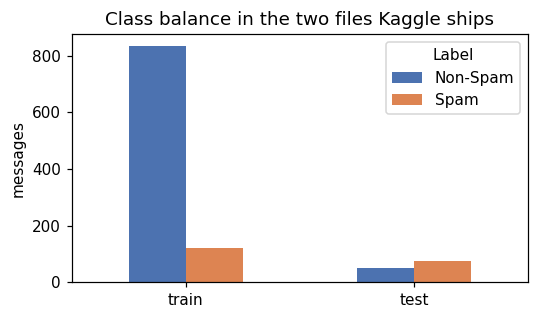

In [4]:
balance = pd.DataFrame({
    "train": train_df["Label"].value_counts(),
    "test": test_df["Label"].value_counts(),
}).reindex(["Non-Spam", "Spam"])
balance.loc["total"] = balance.sum()
display(balance)
print(f"spam share: train {y_train.mean():.1%}   test {y_test.mean():.1%}")

fig, ax = plt.subplots(figsize=(5, 3))
balance.loc[["Non-Spam", "Spam"]].T.plot.bar(ax=ax, rot=0, color=["#4C72B0", "#DD8452"])
ax.set_ylabel("messages")
ax.set_title("Class balance in the two files Kaggle ships")
plt.tight_layout()
plt.show()

Two things to notice, both of which we come back to later:

1. **The training set is spam-minority (12.7 %) while the test set is spam-majority (60.8 %).** The test file
   is also sorted with its spam messages first, which is why `test_df.head()` shows only spam. Our model has
   no notion of row order, so this is harmless — but it means accuracy on the test set would be a poor
   summary, and the F1 score on the Spam class is the right thing to look at.
2. From here until Part 5, **`test_texts` / `y_test` are not used for anything except showing how the
   feature pipeline transforms a few test messages** (Part 2, as the assignment asks). All decisions —
   vocabulary, feature scaling, hyperparameters — are made from the training set alone, using
   cross-validation inside it.

## Part 2 — Feature engineering

A neural network needs numbers, so every message is turned into one fixed-length vector. We build it from
two blocks, both implemented by hand in `src/features.py`:

### 2.1 Tokenisation with placeholders
`tokenize()` lower-cases the text, replaces every **URL** by `__url__`, every run of **7+ digits** (a phone
number, spaces allowed) by `__phone__` and every other **number** by `__num__`, then splits on anything that is
not a letter/digit and drops 1-character tokens.
*Why:* spam almost always contains *some* phone number, *some* price or *some* link, but rarely the same one
twice. With placeholders the model can learn "contains a phone number" from a handful of examples instead of
having to memorise each number.

### 2.2 TF-IDF bag of words
For every token in a vocabulary learned **from the training messages only** (tokens that appear in at least
2 training messages, at most the 2 000 most frequent) we compute

$$\text{tf-idf}(t, m) = \text{tf}(t, m)\cdot\Big(\ln\frac{1+N}{1+\text{df}(t)} + 1\Big),$$

where tf is the count of token *t* in message *m*, *N* the number of training messages and df(*t*) the number
of training messages containing *t*. Each message vector is then L2-normalised.
*Why:* tf captures what the message talks about; idf down-weights tokens that appear everywhere ("to", "the")
and up-weights rare, discriminative ones ("prize", "claim"); normalisation stops long messages from
dominating simply because they contain more words.

### 2.3 Seven handcrafted cues (extra feature engineering)
`handcrafted_features()` adds message length in characters and words, the number of digits, the share of
upper-case letters, the number of `!`, and two flags: *contains a currency symbol* and *contains a URL or a
phone number*. These are standardised (z-scored) with means and standard deviations computed on the training
set. *Why:* they capture the *style* of spam — long, shouting, full of numbers and calls to action — which a
bag of words only sees indirectly. Whether they actually help is tested as a hyperparameter in Part 4.

`FeaturePipeline` glues the blocks together: `fit(texts)` learns vocabulary, idf, means and stds from the
training texts; `transform(texts)` applies them to any texts.

In [5]:
pipe = FeaturePipeline(max_features=2000, min_df=2, use_extra=True).fit(train_texts)
X_train = pipe.transform(train_texts)
print(f"vocabulary size: {len(pipe.tfidf_.vocabulary_)}   handcrafted: {len(HANDCRAFTED_NAMES)}   "
      f"total features: {pipe.n_features_}   X_train: {X_train.shape} {X_train.dtype}")
print("a few vocabulary entries:", pipe.tfidf_.feature_names_[:8], "...", pipe.tfidf_.feature_names_[-8:])

vocabulary size: 1142   handcrafted: 7   total features: 1149   X_train: (957, 1149) float32
a few vocabulary entries: ['__num__', '__phone__', '__url__', 'able', 'about', 'abt', 'access', 'account'] ... ['you', 'your', 'yours', 'yourself', 'yr', 'yrs', 'yup', 'zed']


### The transformation on concrete examples

Three training messages and three test messages. The pipeline was fitted on the training set only; running
test messages *through* it uses no test information — it is exactly what happens at prediction time.

In [6]:
def show_pipeline(texts, labels, title):
    print("=" * 100)
    print(title)
    for text, label in zip(texts, labels):
        print("-" * 100)
        print(f"[{LABEL_NAMES[int(label)]}]  {text}")
        print("  tokens         :", tokenize(text))
        print("  top tf-idf     :", [(t, round(w, 3)) for t, w in pipe.tfidf_.explain(text, k=6)])
        raw = handcrafted_features([text])[0]
        scaled = pipe.scaler_.transform([raw])[0]
        print("  handcrafted    :", {n: round(float(v), 2) for n, v in zip(HANDCRAFTED_NAMES, raw)})
        print("  standardised   :", {n: round(float(v), 2) for n, v in zip(HANDCRAFTED_NAMES, scaled)})
        vec = pipe.transform([text])[0]
        print(f"  feature vector : shape {vec.shape}, {np.count_nonzero(vec)} non-zero entries")

# pick examples by rule so the choice is transparent: a spam with a price, a spam with a link, a longer ham
def first_index(texts, labels, label, predicate):
    return next(i for i, (t, l) in enumerate(zip(texts, labels)) if l == label and predicate(t))

train_examples = [
    first_index(train_texts, y_train, 1, lambda t: "£" in t),
    first_index(train_texts, y_train, 1, lambda t: "www" in t.lower() or "http" in t.lower()),
    first_index(train_texts, y_train, 0, lambda t: len(t) > 60),
]
test_examples = [
    first_index(test_texts, y_test, 1, lambda t: "£" in t),
    first_index(test_texts, y_test, 0, lambda t: True),
    first_index(test_texts, y_test, 0, lambda t: len(t) > 60),
]
print("train example indices:", train_examples, "  test example indices:", test_examples)
show_pipeline([train_texts[i] for i in train_examples], y_train[train_examples], "TRAIN examples")
show_pipeline([test_texts[i] for i in test_examples], y_test[test_examples], "TEST examples")

train example indices: [4, 73, 1]   test example indices: [1, 66, 68]
TRAIN examples
----------------------------------------------------------------------------------------------------
[Spam]  This is the 2nd time we have tried 2 contact u. U have won the £750 Pound prize. 2 claim is easy, call 087187272008 NOW1! Only 10p per minute. BT-national-rate.
  tokens         : ['this', 'is', 'the', '__num__', 'nd', 'time', 'we', 'have', 'tried', '__num__', 'contact', 'have', 'won', 'the', '__num__', 'pound', 'prize', '__num__', 'claim', 'is', 'easy', 'call', '__phone__', 'now', '__num__', 'only', '__num__', 'per', 'minute', 'bt', 'national', 'rate']
  top tf-idf     : [('__num__', 0.486), ('have', 0.233), ('pound', 0.232), ('minute', 0.222), ('national', 0.222), ('is', 0.211)]
  handcrafted    : {'n_chars': 160.0, 'n_words': 30.0, 'n_digits': 21.0, 'upper_ratio': 0.09, 'n_exclaim': 1.0, 'has_currency': 1.0, 'has_url_or_phone': 1.0}
  standardised   : {'n_chars': 1.47, 'n_words': 1.39, 'n_dig

## Part 3 — The learning algorithm: a neural network written from scratch

`src/ann.py` implements a **multi-layer perceptron** (feed-forward neural network) in plain NumPy — no
scikit-learn, no PyTorch. It exposes the usual interface: `NeuralNetwork(...)`, `fit(X, y)`, `predict(X)`,
`predict_proba(X)`.

### How it works

**Architecture.** The input vector $x \in \mathbb{R}^d$ passes through zero or more hidden layers and one
output unit:

$$a^{(0)} = x,\qquad z^{(l)} = a^{(l-1)} W^{(l)} + b^{(l)},\qquad a^{(l)} = g\big(z^{(l)}\big),\qquad
\hat{p} = \sigma\big(z^{(L)}\big) = \frac{1}{1+e^{-z^{(L)}}} .$$

$g$ is the hidden activation (`relu`, `tanh` or `sigmoid` — a hyperparameter) and $\hat p$ is the predicted
probability of spam. With `hidden_layers=()` there is only the output unit and the model is exactly
**logistic regression**, which serves as the baseline in Part 4.

**Loss.** Binary cross-entropy, optionally weighting the rare spam class (`class_weight="balanced"` weights
every spam row by $n_{\text{neg}}/n_{\text{pos}}$), plus an optional L2 penalty:

$$\mathcal{L} = -\frac{1}{n}\sum_{i} w_i\Big[y_i\ln \hat p_i + (1-y_i)\ln(1-\hat p_i)\Big]
 + \frac{\lambda}{2}\sum_l \lVert W^{(l)}\rVert^2 .$$

**Back-propagation.** For the sigmoid + cross-entropy output the error signal is simply
$\delta^{(L)} = (\hat p - y)\,w/n$. It is propagated backwards layer by layer,
$\delta^{(l-1)} = \big(\delta^{(l)} W^{(l)\top}\big)\odot g'\big(z^{(l-1)}\big)$, and the gradients are
$\partial\mathcal L/\partial W^{(l)} = a^{(l-1)\top}\delta^{(l)} + \lambda W^{(l)}$ and
$\partial\mathcal L/\partial b^{(l)} = \sum_i \delta^{(l)}_i$.

**Training.** Mini-batch stochastic gradient descent: each epoch shuffles the training rows, and for every
batch of `batch_size` rows the parameters move against the gradient, $W \leftarrow W - \eta\,
\partial\mathcal L/\partial W$, with learning rate $\eta$. Weights start from He (relu) or Xavier
initialisation and biases from zero; the seed makes every run reproducible.

**Hyperparameters** (all constructor arguments): `hidden_layers`, `activation`, `learning_rate`, `epochs`,
`batch_size`, `l2`, `class_weight`, `seed`.

### Is the implementation correct? — gradient check

Hand-written back-propagation fails silently: a wrong gradient still "trains", just badly. So we compare the
analytic gradients with central finite differences $\big(\mathcal L(\theta+\varepsilon)-\mathcal
L(\theta-\varepsilon)\big)/2\varepsilon$ for every single parameter. The same check runs in the unit-test
suite (`tests/test_ann.py`) for every activation, depth, L2 and class-weight setting, and a deliberately
sabotaged gradient is verified to be caught.

In [7]:
import inspect
print(inspect.signature(NeuralNetwork.__init__))
print(NeuralNetwork.__doc__)

(self, hidden_layers=(32,), activation='relu', learning_rate=0.1, epochs=30, batch_size=32, l2=0.0, class_weight=None, seed=0, verbose=False)
Binary classifier with scikit-learn-like fit / predict / predict_proba.

Hyperparameters
---------------
hidden_layers : tuple of ints, units per hidden layer; () = logistic regression
activation    : "relu" | "tanh" | "sigmoid" for the hidden layers (output is always sigmoid)
learning_rate : SGD step size
epochs        : passes over the training set
batch_size    : rows per SGD step
l2            : L2 penalty on the weights (not on biases)
class_weight  : None or "balanced" (positive rows weighted by n_neg / n_pos in the loss)
seed          : controls weight initialisation and mini-batch shuffling



In [8]:
rng = np.random.default_rng(SEED)
X_tiny = rng.normal(size=(12, 6))
y_tiny = (rng.random(12) < 0.4).astype(float)
for hidden, activation in [((), "relu"), ((5,), "relu"), ((6, 4), "tanh"), ((6, 4), "sigmoid")]:
    net = NeuralNetwork(hidden_layers=hidden, activation=activation, l2=0.01, class_weight="balanced", seed=SEED)
    err = gradient_check(net, X_tiny, y_tiny)
    print(f"hidden={hidden!s:<8} activation={activation:<8} worst relative error = {err:.2e}  "
          f"{'OK' if err < 1e-6 else 'BUG'}")

hidden=()       activation=relu     worst relative error = 8.07e-11  OK
hidden=(5,)     activation=relu     worst relative error = 6.64e-11  OK
hidden=(6, 4)   activation=tanh     worst relative error = 2.56e-10  OK
hidden=(6, 4)   activation=sigmoid  worst relative error = 2.05e-09  OK


Relative errors around $10^{-9}$–$10^{-11}$ mean the analytic gradient matches the numerical one to floating
point precision — the back-propagation is right.

### A first model on the training features

One hidden layer of 32 ReLU units, trained on the TF-IDF + handcrafted features from Part 2. The loss curve
shows that SGD is doing its job; how good this configuration really is (and whether others are better) is the
subject of Part 4 — this is only a sanity check on the training set itself.

NeuralNetwork(hidden_layers=(32,), activation='relu', learning_rate=2.0, epochs=40, batch_size=32, l2=0.0, class_weight=None, seed=42)
trainable parameters: 36,833   fit time: 0.3s


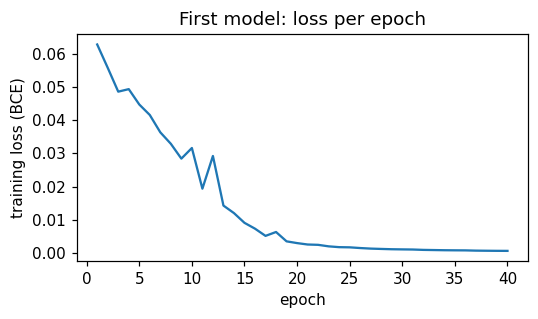

training-set F1 (optimistic - same data it was fitted on): 1.000


In [9]:
first_model = NeuralNetwork(hidden_layers=(32,), activation="relu", learning_rate=2.0, epochs=40,
                            batch_size=32, seed=SEED)
t0 = time.perf_counter()
first_model.fit(X_train, y_train)
print(first_model)
print(f"trainable parameters: {first_model.n_parameters_:,}   fit time: {time.perf_counter() - t0:.1f}s")

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(range(1, len(first_model.loss_history_) + 1), first_model.loss_history_)
ax.set_xlabel("epoch"); ax.set_ylabel("training loss (BCE)"); ax.set_title("First model: loss per epoch")
plt.tight_layout(); plt.show()

train_pred = first_model.predict(X_train)
print(f"training-set F1 (optimistic - same data it was fitted on): {f1_score(y_train, train_pred):.3f}")